**Script: General analysis on the mux0001_b5b7 output, focusing on the global sensitivity**
- Author: Muxin Hu (muxin.hu@mpimet.mpg.de)
- Date created: 17/12/2025
- Lastest modified: 04/01/2026

**Paths**
- the package is downloaded and installed in the directory: `/home/m/m301254/Download/pyicon`

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import pyicon as pyic
import cartopy.crs as ccrs
# from netCDF4 import Dataset
import sys

import cartopy.feature as cfeature
from matplotlib import cm

----Start loading pyicon.
Loading default parameters from /home/m/m301254/Download/pyicon/pyicon/params_default.json.
----Start loading pyicon.
----Pyicon was loaded successfully.
----Pyicon was loaded successfully.


# Specify Raw Data
- notice different for the default and experiment (with different `c_k`)

In [2]:
# data, grid paths
run_def='mux0001_b5b7'
run_ep1='mux0001_b5b7_c_k-03'
run_ep2='mux0001_b5b7_c_k-10'

gname_oce = 'r2b7_oce_r0005'
gname_atm = 'r2b5_atm_r0030'
lev_oce = 'L72'

# data paths
path_data_def = f'/work/mh0033/m301254/proj_surfwave/icon-2025-08-06-XPP/icon-mpim/experiments/{run_def}/outdata/'
path_data_ep1 = f'/work/mh0033/m301254/proj_surfwave/icon-2025-08-06-XPP/icon-mpim/experiments/{run_ep1}/outdata/'

# grid paths
path_grid_oce = f'/home/m/m301254/pyicon_data/grids/{gname_oce}/'
path_grid_atm = f'/home/m/m301254/pyicon_data/grids/{gname_atm}/'

# ckdtree paths
path_ckdtree_oce = f'{path_grid_oce}ckdtree/'
fpath_ckdtree_oce = f'{path_grid_oce}ckdtree/rectgrids/r2b7_oce_r0005_res0.30_180W-180E_90S-90N.nc'
path_ckdtree_atm = f'{path_grid_atm}ckdtree/'
fpath_ckdtree_atm = f'{path_grid_atm}ckdtree/rectgrids/r2b5_atm_r0030_res0.30_180W-180E_90S-90N.nc'

# for ocean; fx file and triangular grid file
fpath_fx = f'{path_grid_oce}{gname_oce}_{lev_oce}_fx.nc'
fpath_tgrid = f'{path_grid_oce}{gname_oce}_tgrid.nc'

# Specify Pre-processed Data
- Notice difference for the default and experiment


In [3]:
# processed data paths
path_prodata_def = f'/work/mh0033/m301254/proj_surfwave/processed_data/{run_def}/'
path_prodata_ep1 = f'/work/mh0033/m301254/proj_surfwave/processed_data/{run_ep1}/'
path_prodata_ep2 = f'/work/mh0033/m301254/proj_surfwave/processed_data/{run_ep2}/'

## 2D dataset, pre-prosessed from `oce_def`
- contains the 2D surface field tos, sos, mld from 1330-1350

### tos, sos, mld fields comparison

In [4]:
# read the preprocessed data
df_def = xr.open_dataset(f'{path_prodata_def}{run_def}_oce_def_2d_1330-1345.nc')
df_ck3 = xr.open_dataset(f'{path_prodata_ep1}{run_ep1}_oce_def_2d_1330-1345.nc')
df_ck10 = xr.open_dataset(f'{path_prodata_ep2}{run_ep2}_oce_def_2d_1330-1345.nc')

/tmp/ipykernel_2036282/643254581.py:2: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  df_def = xr.open_dataset(f'{path_prodata_def}{run_def}_oce_def_2d_1330-1345.nc')
/tmp/ipykernel_2036282/643254581.py:3: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  df_ck3 = xr.open_dataset(f'{path_prodata_ep1}{run_ep1}_oce_def_2d_1330-1345.nc')
/tmp/ipykernel_2036282/643254581.py:4: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  df_ck10 = xr.open_d

In [5]:
# read the climatology for default run (when c_k=0.1)
# then compute the climatological difference between ck=0.3/ck=1.0 and the default run
tos_clim_def = df_def['tos'].mean(dim='time')
tos_diff_ck3 = df_ck3['tos'].mean(dim='time') - tos_clim_def
tos_diff_ck10 = df_ck10['tos'].mean(dim='time') - tos_clim_def

sos_clim_def = df_def['sos'].mean(dim='time')
sos_diff_ck3 = df_ck3['sos'].mean(dim='time') - sos_clim_def
sos_diff_ck10 = df_ck10['sos'].mean(dim='time') - sos_clim_def

mld_clim_def = df_def['mld'].mean(dim='time')
mld_diff_ck3 = df_ck3['mld'].mean(dim='time') - mld_clim_def
mld_diff_ck10 = df_ck10['mld'].mean(dim='time') - mld_clim_def

In [6]:
# define the triangular grid and potential focused region
ds_tg = xr.open_dataset(fpath_tgrid)
# global
ind_glo, Tri_glo = pyic.triangulation(ds_tg)


#### Global comparisons

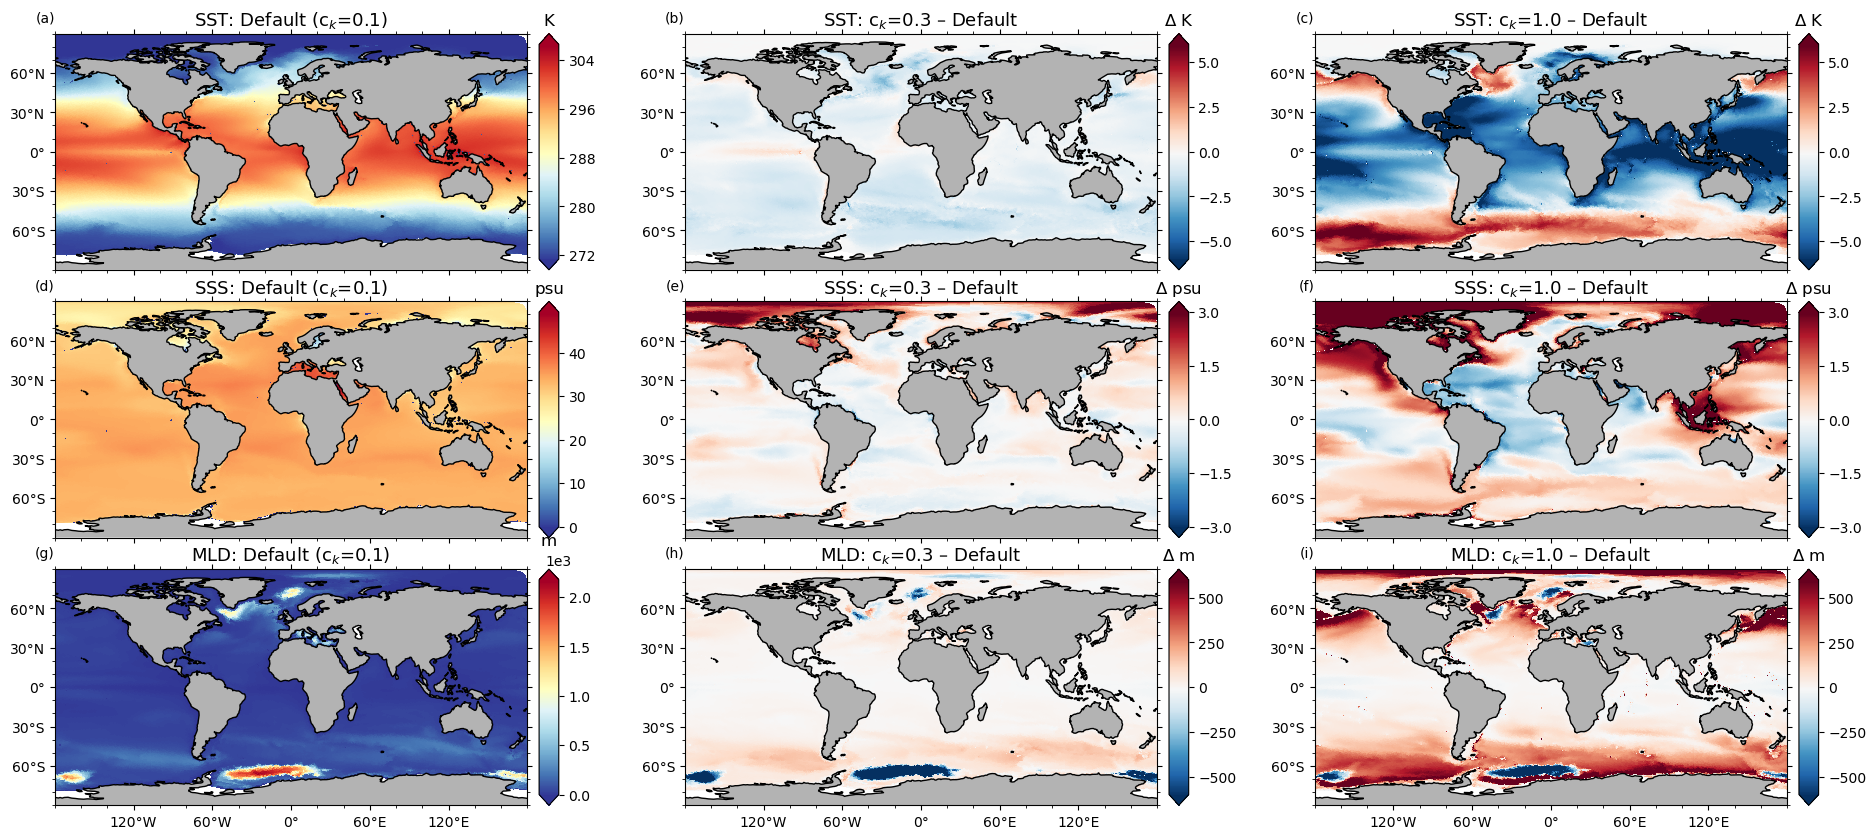

In [ ]:
projection = ccrs.PlateCarree()

# ------------------------------------------------------
# Arrange axes: ONE figure with 3 × 3 subplots
# ------------------------------------------------------
hca, hcb = pyic.arrange_axes(nx=3, ny=3, plot_cb=True, f_hax=0.8
                             asp=0.5, fig_size_fac=2.0, projection=projection)

ii = -1

# ------------------------------------------------------
# Function to plot a row of 3 plots: absolute for default, diff for two experiment runs
# ------------------------------------------------------
def plot_row(field_def, diff1, diff2, varname, diff_clim, unit):
    '''
    plotting function for a row of 3 plots:
    1st: absolute field for default run
    2nd: difference field for experiment run 1 minus default
    3rd: difference field for experiment run 2 minus default
    '''
    global ii
    vmin = field_def.min()
    vmax = field_def.max()

    # --- absolute
    ii += 1
    ax = hca[ii]; cax = hcb[ii]
    pyic.shade(Tri_glo, field_def,
               ax=ax, cax=cax, clim=(vmin, vmax))
    ax.set_title(f"{varname}: Default (c$_k$=0.1)", fontsize=13)
    # ax.set_xlabel("longitude")
    # ax.set_ylabel("latitude")
    pyic.plot_settings(ax, template="global")
    cax.set_title(unit)

    # --- diff 1
    ii += 1
    ax = hca[ii]; cax_diff = hcb[ii]
    pyic.shade(Tri_glo, diff1,
               ax=ax, cax=cax_diff, clim=diff_clim)
    ax.set_title(f"{varname}: c$_k$=0.3 – Default", fontsize=13)
    # ax.set_xlabel("longitude")
    # ax.set_ylabel("latitude")
    pyic.plot_settings(ax, template="global")
    cax_diff.set_title(r"$\Delta$ " + unit)

    # --- diff 2 (shared colorbar)
    ii += 1
    ax = hca[ii]; cax_diff = hcb[ii]
    pyic.shade(Tri_glo, diff2,
               ax=ax, cax=cax_diff, clim=diff_clim)
    ax.set_title(f"{varname}: c$_k$=1.0 – Default", fontsize=13)
    # ax.set_xlabel("longitude")
    # ax.set_ylabel("latitude")
    pyic.plot_settings(ax, template="global")
    cax_diff.set_title(r"$\Delta$ " + unit)



# ------------------------------------------------------
# Plot rows
# ------------------------------------------------------
plot_row(tos_clim_def, tos_diff_ck3, tos_diff_ck10,
         "SST", (-6.0, 6.0), "K")

plot_row(sos_clim_def, sos_diff_ck3, sos_diff_ck10,
         "SSS", (-3.0, 3.0), "psu")

plot_row(mld_clim_def, mld_diff_ck3, mld_diff_ck10,
         "MLD", (-600.0, 600.0), "m")


# ------------------------------------------------------
# SAVE FIGURE
# ------------------------------------------------------
fig = plt.gcf()

# fig.subplots_adjust(hspace=0.25)

outpath = "/home/m/m301254/project_surfwaves/figs"
outfile = f"{outpath}/clim_and_diff_SST_SSS_MLD_ck_sensitivity.png"

fig.savefig(
    outfile,
    dpi=150,
    bbox_inches="tight",
    facecolor="white"
)

# plt.close(fig)


#### Regional Comparison (Southeast Pacific)

In [47]:
# regional: southeast Pacific
lon_reg = [-90, -70]
lat_reg = [-20, 0]
ind_reg, Tri_reg = pyic.triangulation(ds_tg, lon_reg=lon_reg, lat_reg=lat_reg)

In [48]:
tos_clim_def_reg = tos_clim_def.isel(ncells=ind_reg)
tos_diff_ck3_reg = tos_diff_ck3.isel(ncells=ind_reg)
tos_diff_ck10_reg = tos_diff_ck10.isel(ncells=ind_reg)

sos_clim_def_reg = sos_clim_def.isel(ncells=ind_reg)
sos_diff_ck3_reg = sos_diff_ck3.isel(ncells=ind_reg)
sos_diff_ck10_reg = sos_diff_ck10.isel(ncells=ind_reg)

mld_clim_def_reg = mld_clim_def.isel(ncells=ind_reg)
mld_diff_ck3_reg = mld_diff_ck3.isel(ncells=ind_reg)
mld_diff_ck10_reg = mld_diff_ck10.isel(ncells=ind_reg)

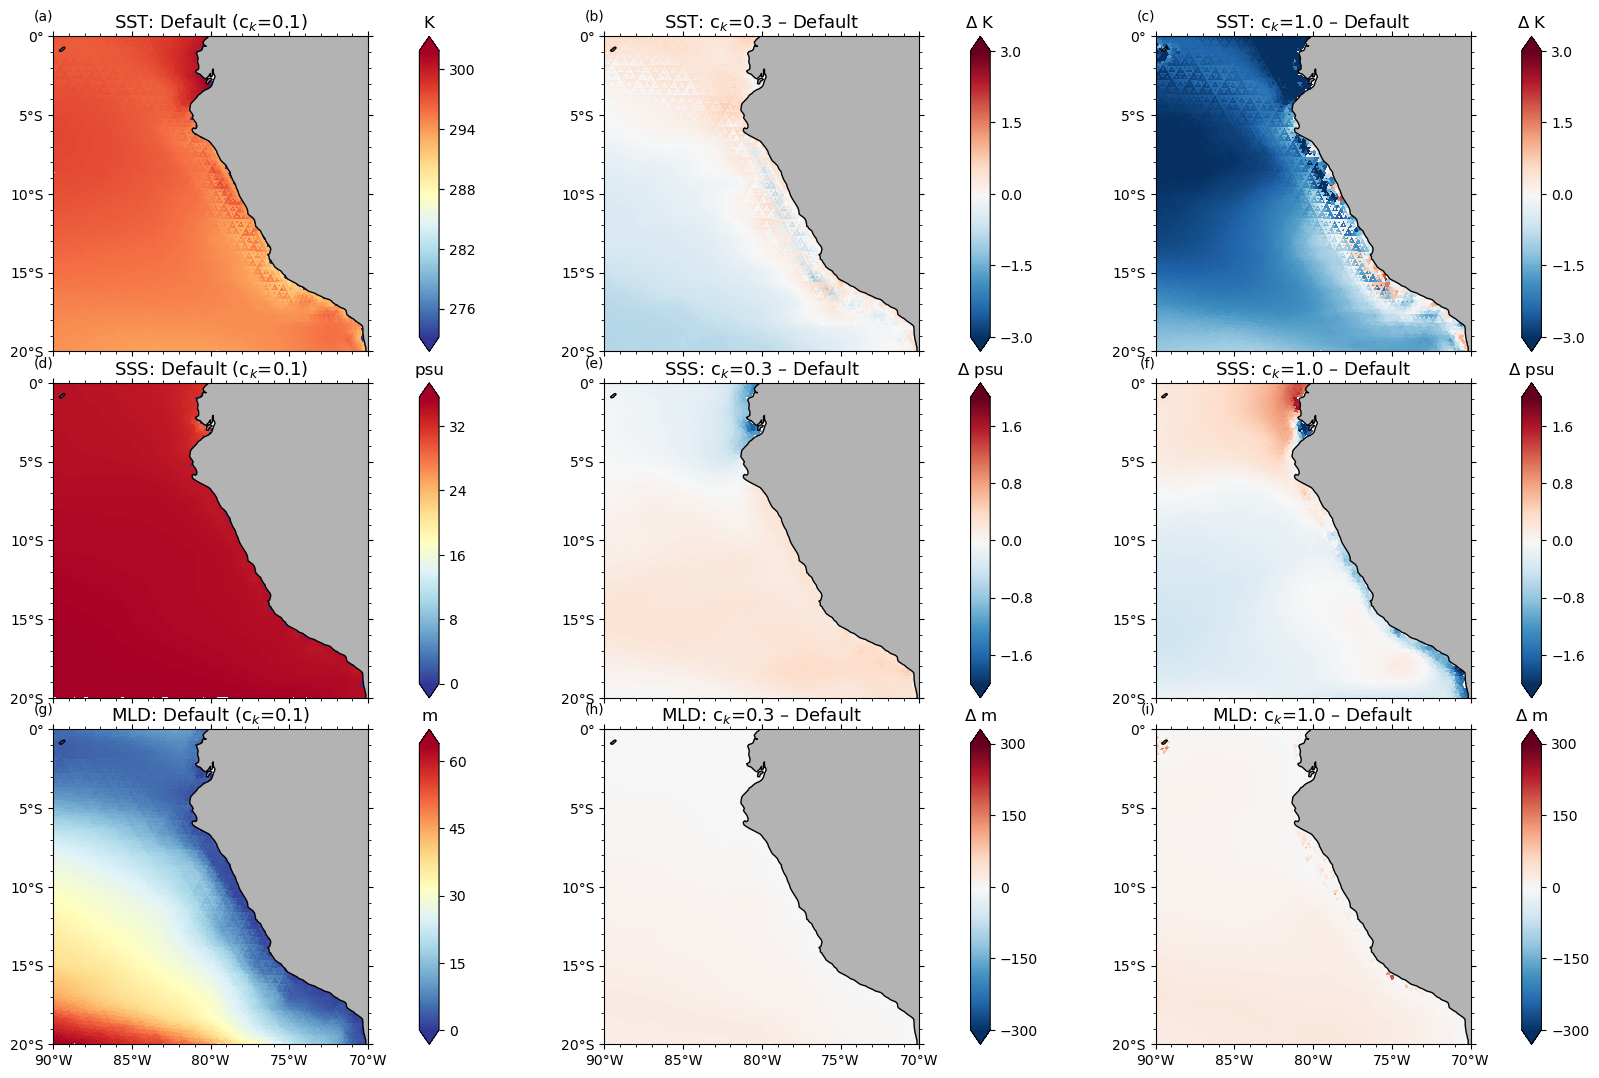

In [51]:
projection = ccrs.PlateCarree()

# ------------------------------------------------------
# Arrange axes: ONE figure with 3 × 3 subplots
# ------------------------------------------------------
hca, hcb = pyic.arrange_axes(nx=3, ny=3, plot_cb=True,
                             asp=0.8, fig_size_fac=2.0, projection=projection)

ii = -1

# ------------------------------------------------------
# Function to plot a row of 3 plots: absolute for default, diff for two experiment runs
# ------------------------------------------------------
def plot_row_regional(field_def, diff1, diff2, varname, diff_clim, unit):
    '''
    plotting function for a row of 3 plots:
    1st: absolute field for default run
    2nd: difference field for experiment run 1 minus default
    3rd: difference field for experiment run 2 minus default
    '''
    global ii
    vmin = field_def.min()
    vmax = field_def.max()

    # --- absolute
    ii += 1
    ax = hca[ii]; cax = hcb[ii]
    pyic.shade(Tri_reg, field_def,
               ax=ax, cax=cax, clim=(vmin, vmax))
    ax.set_title(f"{varname}: Default (c$_k$=0.1)", fontsize=13)
    # ax.set_xlabel("longitude")
    # ax.set_ylabel("latitude")
    pyic.plot_settings(ax, xlim=lon_reg, ylim=lat_reg)
    cax.set_title(unit)

    # --- diff 1
    ii += 1
    ax = hca[ii]; cax_diff = hcb[ii]
    pyic.shade(Tri_reg, diff1,
               ax=ax, cax=cax_diff, clim=diff_clim)
    ax.set_title(f"{varname}: c$_k$=0.3 – Default", fontsize=13)
    # ax.set_xlabel("longitude")
    # ax.set_ylabel("latitude")
    pyic.plot_settings(ax, xlim=lon_reg, ylim=lat_reg)
    cax_diff.set_title(r"$\Delta$ " + unit)

    # --- diff 2 (shared colorbar)
    ii += 1
    ax = hca[ii]; cax_diff = hcb[ii]
    pyic.shade(Tri_reg, diff2,
               ax=ax, cax=cax_diff, clim=diff_clim)
    ax.set_title(f"{varname}: c$_k$=1.0 – Default", fontsize=13)
    # ax.set_xlabel("longitude")
    # ax.set_ylabel("latitude")
    pyic.plot_settings(ax, xlim=lon_reg, ylim=lat_reg)
    cax_diff.set_title(r"$\Delta$ " + unit)



# ------------------------------------------------------
# Plot rows
# ------------------------------------------------------
plot_row_regional(tos_clim_def_reg, tos_diff_ck3_reg, tos_diff_ck10_reg,
         "SST", (-3.0, 3.0), "K")

plot_row_regional(sos_clim_def_reg, sos_diff_ck3_reg, sos_diff_ck10_reg,
         "SSS", (-2.0, 2.0), "psu")

plot_row_regional(mld_clim_def_reg, mld_diff_ck3_reg, mld_diff_ck10_reg,
         "MLD", (-300.0, 300.0), "m")


# ------------------------------------------------------
# SAVE FIGURE
# ------------------------------------------------------
fig = plt.gcf()

# fig.subplots_adjust(hspace=0.25)

outpath = "/home/m/m301254/project_surfwaves/figs"
outfile = f"{outpath}/clim_and_diff_SST_SSS_MLD_ck_sensitivity_PeruCoast.png"

# fig.savefig(
#     outfile,
#     dpi=150,
#     bbox_inches="tight",
#     facecolor="white"
# )

# plt.close(fig)


#### Peruvian Coastal upwelling region

In [34]:
# regional: smaller Pacific
lon_reg = [-83, -76]
lat_reg = [-14, -4]
ind_reg, Tri_reg = pyic.triangulation(ds_tg, lon_reg=lon_reg, lat_reg=lat_reg)

tos_clim_def_reg = tos_clim_def.isel(ncells=ind_reg)
tos_diff_ck3_reg = tos_diff_ck3.isel(ncells=ind_reg)
tos_diff_ck10_reg = tos_diff_ck10.isel(ncells=ind_reg)

sos_clim_def_reg = sos_clim_def.isel(ncells=ind_reg)
sos_diff_ck3_reg = sos_diff_ck3.isel(ncells=ind_reg)
sos_diff_ck10_reg = sos_diff_ck10.isel(ncells=ind_reg)

mld_clim_def_reg = mld_clim_def.isel(ncells=ind_reg)
mld_diff_ck3_reg = mld_diff_ck3.isel(ncells=ind_reg)
mld_diff_ck10_reg = mld_diff_ck10.isel(ncells=ind_reg)

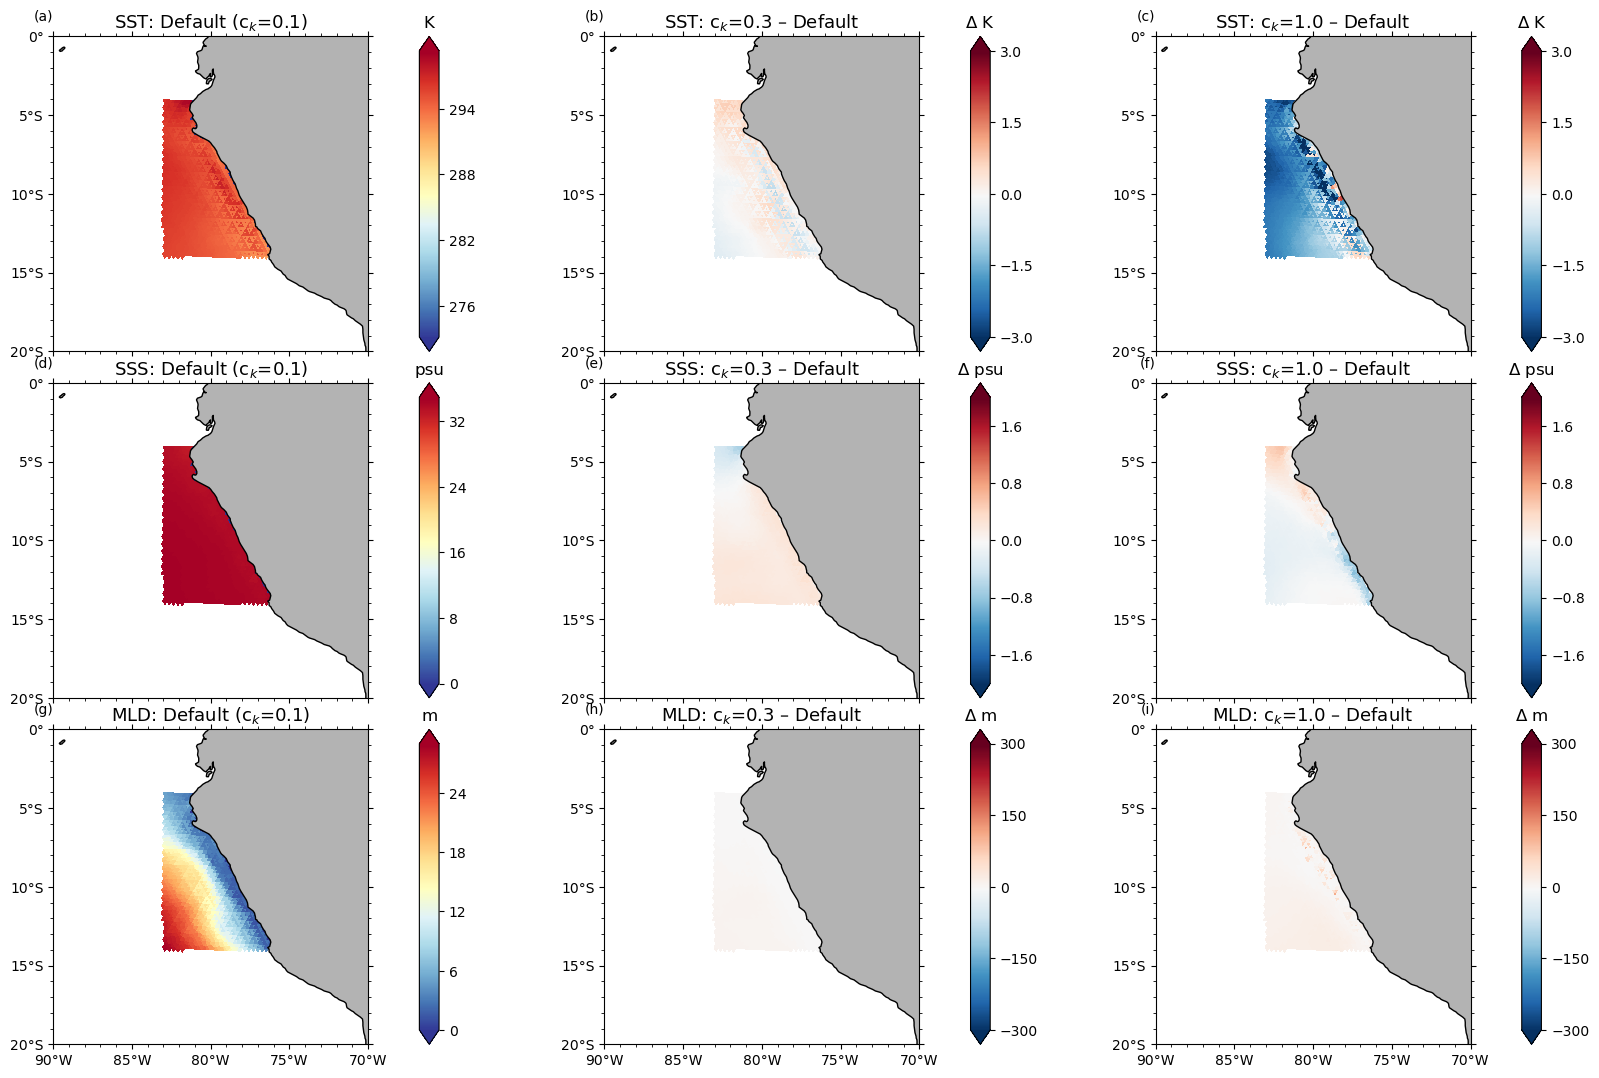

In [35]:
projection = ccrs.PlateCarree()

# lon and lat range for broader plotting area
lon_reg_broad = [-90, -70]
lat_reg_broad = [-20, 0]

# ------------------------------------------------------
# Arrange axes: ONE figure with 3 × 3 subplots
# ------------------------------------------------------
hca, hcb = pyic.arrange_axes(nx=3, ny=3, plot_cb=True,
                             asp=0.8, fig_size_fac=2.0, projection=projection)

ii = -1

# ------------------------------------------------------
# Function to plot a row of 3 plots: absolute for default, diff for two experiment runs
# ------------------------------------------------------
def plot_row_regional(field_def, diff1, diff2, varname, diff_clim, unit):
    '''
    plotting function for a row of 3 plots:
    1st: absolute field for default run
    2nd: difference field for experiment run 1 minus default
    3rd: difference field for experiment run 2 minus default
    '''
    global ii
    vmin = field_def.min()
    vmax = field_def.max()

    # --- absolute
    ii += 1
    ax = hca[ii]; cax = hcb[ii]
    pyic.shade(Tri_reg, field_def,
               ax=ax, cax=cax, clim=(vmin, vmax))
    ax.set_title(f"{varname}: Default (c$_k$=0.1)", fontsize=13)
    # ax.set_xlabel("longitude")
    # ax.set_ylabel("latitude")
    pyic.plot_settings(ax, xlim=lon_reg_broad, ylim=lat_reg_broad)
    cax.set_title(unit)

    # --- diff 1
    ii += 1
    ax = hca[ii]; cax_diff = hcb[ii]
    pyic.shade(Tri_reg, diff1,
               ax=ax, cax=cax_diff, clim=diff_clim)
    ax.set_title(f"{varname}: c$_k$=0.3 – Default", fontsize=13)
    # ax.set_xlabel("longitude")
    # ax.set_ylabel("latitude")
    pyic.plot_settings(ax, xlim=lon_reg_broad, ylim=lat_reg_broad)
    cax_diff.set_title(r"$\Delta$ " + unit)

    # --- diff 2 (shared colorbar)
    ii += 1
    ax = hca[ii]; cax_diff = hcb[ii]
    pyic.shade(Tri_reg, diff2,
               ax=ax, cax=cax_diff, clim=diff_clim)
    ax.set_title(f"{varname}: c$_k$=1.0 – Default", fontsize=13)
    # ax.set_xlabel("longitude")
    # ax.set_ylabel("latitude")
    pyic.plot_settings(ax, xlim=lon_reg_broad, ylim=lat_reg_broad)
    cax_diff.set_title(r"$\Delta$ " + unit)



# ------------------------------------------------------
# Plot rows
# ------------------------------------------------------
plot_row_regional(tos_clim_def_reg, tos_diff_ck3_reg, tos_diff_ck10_reg,
         "SST", (-3.0, 3.0), "K")

plot_row_regional(sos_clim_def_reg, sos_diff_ck3_reg, sos_diff_ck10_reg,
         "SSS", (-2.0, 2.0), "psu")

plot_row_regional(mld_clim_def_reg, mld_diff_ck3_reg, mld_diff_ck10_reg,
         "MLD", (-300.0, 300.0), "m")


# ------------------------------------------------------
# SAVE FIGURE
# ------------------------------------------------------
fig = plt.gcf()

# fig.subplots_adjust(hspace=0.25)

outpath = "/home/m/m301254/project_surfwaves/figs"
outfile = f"{outpath}/clim_and_diff_SST_SSS_MLD_ck_sensitivity_PeruCoast_focus.png"

# fig.savefig(
#     outfile,
#     dpi=150,
#     bbox_inches="tight",
#     facecolor="white"
# )

# plt.close(fig)
